# Null models and permutation testing

We touched on null models briefly in [Notebook 1](intro1_spatial_colocalizations.ipynb) (conceptual background) and [Notebook 2](intro2_nispace_intro.ipynb) (where we called `permute("maps")` without much explanation). This notebook explains what's happening under the hood and when to use which approach.

There are two fundamentally different situations that call for different null models:

1. **You have a single group-level map** (e.g., the pain NeuroQuery map, a published effect size): permute the *reference maps*.
2. **You have individual subject data and a group design** (e.g., the anorexia nervosa dataset): permute the *group labels*.

For X-Set Enrichment Analysis, there's a third type — we'll cover that in [Notebook 10](intro10_xsea.ipynb).

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img
from nispace.api import NiSpace

# set up with the pain map
pet_maps = fetch_reference("pet", parcellation="Schaefer200",
                           collection="UniqueTracers", print_references=False)
pain_map = load_img("neuroquery/pain.nii.gz")

nsp = NiSpace(x=pet_maps, y=pain_map, y_labels="Pain",
              parcellation="Schaefer200", seed=42, n_proc=4)
nsp.fit()
nsp.colocalize("spearman")

INFO | 31/05/26 13:29:27 | nispace.datasets: Loading pet maps.


INFO | 31/05/26 13:29:27 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 31/05/26 13:29:27 | nispace.datasets: Filtering maps by collection.


INFO | 31/05/26 13:29:27 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


Updating /Users/llotter/nispace-data/reference/pet/tab/dset-pet_parc-Schaefer200Parcels7Networks.csv.gz
INFO | 31/05/26 13:29:27 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

INFO | 31/05/26 13:29:31 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 31/05/26 13:29:31 | nispace.api: Running 'spearman' colocalization.


INFO | 31/05/26 13:29:31 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc):   0%|                                                                                                                                                                                             | 0/1 [00:00<?, ?it/s]

Colocalizing (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2045.00it/s]

## Part 1: Surrogate map null models

When you call `permute("maps")`, NiSpace generates spatially-constrained random versions of the reference maps and recomputes the correlation with your input map for each permutation. The empirical distribution of these null correlations becomes the null distribution.

The null method is **auto-selected** based on the parcellation type — you rarely need to specify it explicitly:

- **Cortical-only parcellations** with a surface space (fsLR, fsaverage): spin test (`"alexander_bloch"`) is chosen automatically
- **Combined (cortex + subcortex) or volumetric-only parcellations**: Moran spectral randomization (`"moran"`) is chosen automatically

Three methods are available in total (more are continuously added):

| Method | Key idea | When selected |
|--------|----------|---------------|
| `"alexander_bloch"` (spin) | Random rotations on the cortical sphere, automatically retaining interhemispheric symmetry to a large extent | **Auto-default** for cortical parcellations (e.g., Schaefer200) |
| `"moran"` (Moran spectral randomization) | Randomize spectral coefficients of the spatial covariance, null map symmetry will depend on distance matrix symmetry | **Auto-default** for combined/volumetric parcellations |
| `"burt2020"` (variogram) | Match the spatial variogram of the original map, null map symmetry will depend on distance matrix symmetry | Explicit choice; any parcellation |

Schaefer200 is a cortical-only atlas with fsLR available, so the spin test is selected automatically when we omit `null_method`.

### The spin test (alexander_bloch)

The spin test (Alexander-Bloch et al., 2018) works by projecting the cortical parcellation onto a sphere and applying random rotations. This preserves the spatial topology of the original map while breaking any specific spatial relationship with the input map.

In [3]:
# spin test — auto-selected for Schaefer200 (cortical + fsLR), so null_method can be omitted
nsp.permute("maps", n_perm=10000, p_tails="upper")
p_spin = nsp.get_p_values()
print("Spin test — 5 lowest p-values:")
p_spin.T.sort_values(by="Pain").head(5)

INFO | 31/05/26 13:29:34 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 31/05/26 13:29:34 | nispace.api: Permutation of: X maps.


INFO | 31/05/26 13:29:34 | nispace.api: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').


INFO | 31/05/26 13:29:34 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 31/05/26 13:29:34 | nispace.api: Loading observed colocalizations (method = 'spearman').


...

Null colocalizations (spearman, 4 proc):  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 8184/10000 [00:00<00:00, 13895.66it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 14856.33it/s]

INFO | 31/05/26 13:29:52 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Spin test — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.0096
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.0160
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.0508
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.0731
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.1668


### Moran Spectral Randomization (moran)

Moran spectral randomization is automatically selected when the spin test is not applicable — specifically for **combined (cortex + subcortex)** or **volumetric-only** parcellations that have no spherical surface projection.

It works by decomposing the spatial covariance structure of the parcellation into eigenvectors (Moran eigenvectors), then randomizing the spectral coefficients while preserving the overall structure. The result is a null map with the same degree of spatial autocorrelation, but with the specific spatial pattern scrambled.

Two key properties:
1. **Works with any parcellation geometry** — subcortical structures, volumetric atlases, anything.
2. **No precomputed matrix needed** — eigenvectors are derived on the fly from the parcellation distance matrix.

With Schaefer200 the spin test is the auto-selected default, so to run Moran we specify `null_method="moran"` explicitly:

In [4]:
nsp.permute("maps", maps_method="moran", n_perm=10000, p_tails="upper")
p_moran = nsp.get_p_values()
print("Moran spectral — 5 lowest p-values:")
p_moran.T.sort_values(by="Pain").head(5)

INFO | 31/05/26 13:29:52 | nispace.core.permute: Found existing null maps.


WARNING | 31/05/26 13:29:52 | nispace.core.permute: Null method changed. Will re-generate.


INFO | 31/05/26 13:29:52 | nispace.core.permute: Generating null maps (n = 10000, null_method = 'moran').


INFO | 31/05/26 13:29:52 | nispace.nulls: Null map generation: Assuming n = 29 data vector(s) for n = 200 parcels.


INFO | 31/05/26 13:29:52 | nispace.nulls: Using provided distance matrix/matrices.


...

Null colocalizations (spearman, 4 proc):  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 8184/10000 [00:00<00:00, 14851.28it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 16277.65it/s]

INFO | 31/05/26 13:30:01 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Moran spectral — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.0065
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.0331
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.0453
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.0628
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.0772


In [5]:
# compare spin and Moran side by side
comparison = pd.DataFrame({
    "rho": nsp.get_colocalizations().T["Pain"],
    "p_spin": p_spin.T["Pain"],
    "p_moran": p_moran.T["Pain"],
}).sort_values("p_spin")
comparison.head(10)

,,rho,p_spin,p_moran
set,map,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.435971,0.0096,0.0065
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.339014,0.0160,0.0331
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.309315,0.0508,0.0453
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.304823,0.0731,0.0772
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.219451,0.1668,0.0628
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.176491,0.2262,0.2286
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.151909,0.2499,0.1267
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.129229,0.2689,0.2881
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.111743,0.3244,0.2972


## Part 2: Group permutation

When you have individual subject data and a group comparison design, permuting the reference maps isn't quite right — you should permute the group labels instead. The logic is:

> If the colocalization between the patient effect size map and a reference map is real, then randomly reassigning subjects to groups should produce smaller effect sizes, and hence smaller colocalizations.

This is implemented with `permute("groups")`. We use the anorexia nervosa example dataset below.

> **Note:** This dataset is **simulated** and not intended for scientific use.

In [6]:
# set up with the anorexia nervosa dataset
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

nsp_groups = NiSpace(x=pet_maps, y=an_data, parcellation="Schaefer200",
                     seed=42, n_proc=4)
nsp_groups.fit()

# compute effect sizes first
nsp_groups.transform_y(transform="hedges(a,b)", groups=groups)
nsp_groups.colocalize("spearman")

# group permutation: randomly shuffle the AN/HC labels and recompute
nsp_groups.permute(
    "groups",
    groups=groups,
    n_perm=10000,
    p_tails="two"  # two-tailed: we don't have a directional hypothesis here
)
p_groups = nsp_groups.get_p_values()
y_label = p_groups.index[0]
print(f"Group permutation ({y_label}) — 5 lowest p-values:")
p_groups.T.sort_values(by=y_label).head(5)

INFO | 31/05/26 13:30:01 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200Parcels7Networks.


INFO | 31/05/26 13:30:01 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200Parcels7Networks' from library.


INFO | 31/05/26 13:30:01 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR


INFO | 31/05/26 13:30:01 | nispace.core.parcellation:   No pre-computed spin matrix for 'Schaefer200Parcels7Networks' in 'fsaverage'.


INFO | 31/05/26 13:30:01 | nispace.core.parcellation:   No pre-computed spin matrix for 'Schaefer200Parcels7Networks' in 'fsLR'.


...

Null colocalizations (spearman, 4 proc):  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 8184/10000 [00:00<00:00, 32621.21it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 38171.02it/s]

INFO | 31/05/26 13:30:03 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Group permutation (mean) — 5 lowest p-values:


,,mean
set,map,
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.0001
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.0001
Dopamine,target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-garciagomez2018,0.0001
Serotonin,target-5HT1a_tracer-way100635_n-35_dx-hc_pub-savli2012,0.0044
Dopamine,target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller2017,0.0054


### Which null model should I use?

A practical guide:

| Situation | Recommended null model |
|-----------|------------------------|
| Single cortical map (published effect size, meta-analytic map) | `permute("maps")` — spin auto-selected for Schaefer200 and similar cortical atlases |
| Single map with combined or subcortical parcellation | `permute("maps")` — Moran auto-selected |
| Individual subject data with group comparison | `permute("groups")` |
| XSEA (set enrichment) | `permute("maps")` by default — see [Notebook 10](intro10_xsea.ipynb) |

Group permutation is more computationally expensive (the effect size must be recomputed for each permutation) but is more appropriate when you have individual-level data.

## Part 3: Visualizing the null distribution

After calling `permute()`, the null distribution is stored internally and used when you call `nsp.plot()`. The grey shading in the plot represents the null distribution percentiles.

INFO | 31/05/26 13:30:05 | nispace.plotting: Significance annotation: 3/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


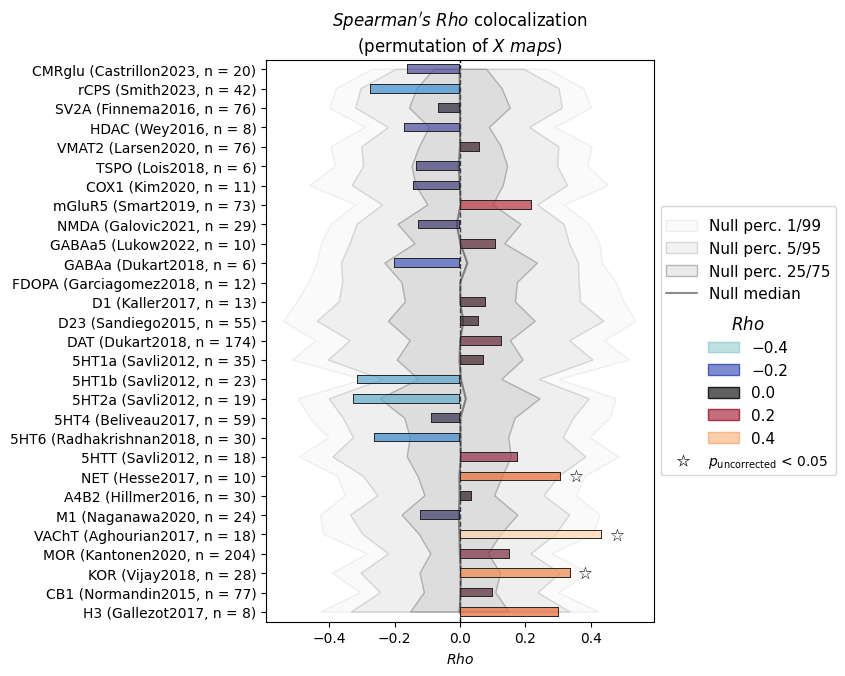

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x17ec5ceb0>)

In [7]:
# plot with null distribution shading
nsp.plot()

## Summary

- `permute("maps")` without specifying `null_method` — auto-selects spin for cortical parcellations, Moran for combined/volumetric
- `permute("maps", null_method="alexander_bloch")` — spin test; for cortical surface parcellations
- `permute("maps", null_method="moran")` — Moran spectral; for combined or volumetric parcellations, or as explicit override
- `permute("maps", null_method="burt2020")` — variogram matching; works with any parcellation
- `permute("groups", groups=...)` — group label permutation; preferred for individual subject data
- All methods produce empirical p-values stored in the NiSpace object, retrievable with `get_p_values()`

Next: [Notebook 6](intro6_multiple_comparisons.ipynb) covers multiple comparisons correction — because running 29 receptor tests at once without correction is not a great idea.